# Analiza 1: Degradacija guma (linearna regresija)

**Hipoteza:** Vreme po krugu (lap time) raste linearno sa starošću guma (tyre age) u okviru
istog stinta, i taj rast (nagib prave) zavisi od tipa gume (SOFT/MEDIUM/HARD).

**Metod:** Za svaki krug spajamo `laps.csv` (vreme kruga) sa `stints.csv` (koji stint i koja
guma je bila aktivna) da bismo izračunali starost gume u tom krugu. Zatim radimo linearnu
regresiju `lap_duration ~ tyre_age` odvojeno po tipu gume, koristeći `scipy.stats.linregress`
(nagib, R², p-vrednost).

**Kome je ovo bitno:** Strateškim inženjerima (race strategists) - kvantifikovan nagib
degradacije direktno određuje optimalni prozor za "pit stop" (kada je jeftinije stati po nove
gume nego nastaviti da gubi vreme na starim).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("F1Analysis").getOrCreate()


DATA_DIR = "../data/processed"


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/07 00:08:35 WARN Utils: Your hostname, Ognjens-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.55 instead (on interface en0)
26/07/07 00:08:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/07 00:08:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
from pyspark.sql import functions as F

laps = spark.read.csv(f"{DATA_DIR}/laps.csv", header=True, inferSchema=True)
stints = spark.read.csv(f"{DATA_DIR}/stints.csv", header=True, inferSchema=True)


laps_clean = (
    laps.filter((F.col("is_pit_out_lap") == False) & F.col("lap_duration").isNotNull())
)

laps_clean.select("driver_number", "lap_number", "lap_duration").show(5)
stints.select("driver_number", "stint_number", "lap_start", "lap_end", "compound", "tyre_age_at_start").show(5)


+-------------+----------+------------+
|driver_number|lap_number|lap_duration|
+-------------+----------+------------+
|            1|         1|      72.441|
|            4|         1|      73.675|
|           11|         1|      76.622|
|           16|         1|      82.511|
|           44|         1|      75.234|
+-------------+----------+------------+
only showing top 5 rows
+-------------+------------+---------+-------+--------+-----------------+
|driver_number|stint_number|lap_start|lap_end|compound|tyre_age_at_start|
+-------------+------------+---------+-------+--------+-----------------+
|            1|           1|        1|     23|  MEDIUM|                0|
|            1|           2|       24|     51|    HARD|                0|
|            1|           3|       52|     64|  MEDIUM|                3|
|            1|           4|       65|     71|    SOFT|                0|
|            4|           1|        1|     23|  MEDIUM|                0|
+-------------+---------

In [3]:

laps_clean.createOrReplaceTempView("laps")
stints.createOrReplaceTempView("stints")

lap_tyre_age = spark.sql("""
    SELECT
        l.driver_number,
        l.lap_number,
        l.lap_duration,
        s.compound,
        s.tyre_age_at_start + (l.lap_number - s.lap_start) AS tyre_age
    FROM laps l
    JOIN stints s
      ON l.driver_number = s.driver_number
     AND l.lap_number BETWEEN s.lap_start AND s.lap_end
""")

lap_tyre_age.orderBy("driver_number", "lap_number").show(10)
print("Ukupno krugova sa poznatom starošću gume:", lap_tyre_age.count())


+-------------+----------+------------+--------+--------+
|driver_number|lap_number|lap_duration|compound|tyre_age|
+-------------+----------+------------+--------+--------+
|            1|         1|      72.441|  MEDIUM|       0|
|            1|         2|      69.938|  MEDIUM|       1|
|            1|         3|      69.857|  MEDIUM|       2|
|            1|         4|      69.903|  MEDIUM|       3|
|            1|         5|      70.005|  MEDIUM|       4|
|            1|         6|      70.238|  MEDIUM|       5|
|            1|         7|       70.22|  MEDIUM|       6|
|            1|         8|      70.331|  MEDIUM|       7|
|            1|         9|        70.6|  MEDIUM|       8|
|            1|        10|      70.596|  MEDIUM|       9|
+-------------+----------+------------+--------+--------+
only showing top 10 rows


Ukupno krugova sa poznatom starošću gume: 404


In [4]:
from scipy import stats

pdf = lap_tyre_age.toPandas()

pdf = pdf[(pdf["lap_duration"] > pdf["lap_duration"].quantile(0.02)) &
          (pdf["lap_duration"] < pdf["lap_duration"].quantile(0.98))]

results = []
for compound, group in pdf.groupby("compound"):
    if len(group) < 5:
        continue
    slope, intercept, r, p, se = stats.linregress(group["tyre_age"], group["lap_duration"])
    results.append({"compound": compound, "n_laps": len(group), "slope_s_per_lap": slope,
                     "r_squared": r ** 2, "p_value": p})

results_df = pd.DataFrame(results).sort_values("compound")
results_df


,compound,n_laps,slope_s_per_lap,r_squared,p_value
0,HARD,151,0.062936,0.239745,1.768108e-10
1,MEDIUM,234,0.067416,0.117298,7.683051e-08


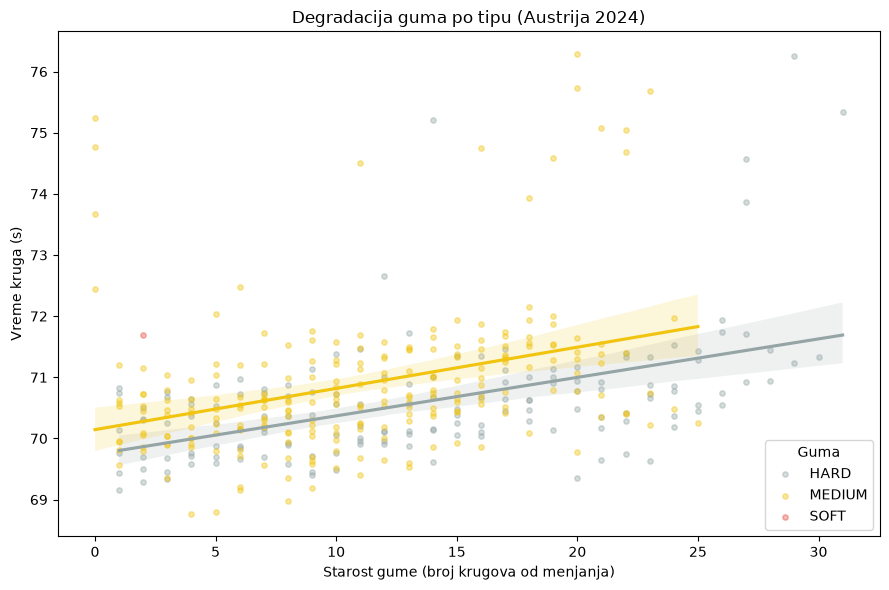

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = {"SOFT": "#e74c3c", "MEDIUM": "#f1c40f", "HARD": "#95a5a6"}
for compound, group in pdf.groupby("compound"):
    color = palette.get(compound, "gray")
    sns.regplot(x="tyre_age", y="lap_duration", data=group, ax=ax, label=compound,
                scatter_kws={"alpha": 0.4, "s": 15, "color": color}, line_kws={"color": color})

ax.set_xlabel("Starost gume (broj krugova od menjanja)")
ax.set_ylabel("Vreme kruga (s)")
ax.set_title("Degradacija guma po tipu (Austrija 2024)")
ax.legend(title="Guma")
plt.tight_layout()
plt.show()


**Zaključak:** Pozitivan i statistički značajan (p < 0.05) nagib za dati tip gume
potvrđuje da guma tog tipa degradira - odnosno da vozač gubi otprilike `slope_s_per_lap`
sekundi po krugu za svaki dodatni krug na toj gumi. Poređenje nagiba između SOFT/MEDIUM/HARD
kvantifikuje koliko je koja guma "brže propadala", što je upravo ono što bi tim za strategiju
koristio da odluči kada napraviti "pit stop".